# Hyperparameter Tuning & Optimisation

This notebook tunes the Gradient Boosted Tree (GBT) regressor — the strongest performing baseline from notebook 5 (R² = 0.9926, RMSE = 30.63) — using SparkML's `TrainValidationSplit` and `ParamGridBuilder`. 

The objective is to systematically search the hyperparameter space and identify the optimal configuration that minimises RMSE on the held-out test set.

The tuning process covers five key hyperparameters:
1. `maxDepth` — controls tree complexity and capacity to capture non-linear patterns
2. `maxIter` — number of boosting iterations (trees in the ensemble)
3. `stepSize` — learning rate; controls the contribution of each tree
4. `subsamplingRate` — fraction of training data sampled per iteration (reduces overfitting)
5. `minInstancesPerNode` — minimum instances required at a leaf node (regularisation)

All tuning uses a temporal train/validation split, preserving chronological order to reflect a realistic traffic forecasting scenario. The best model is evaluated on the same held-out test set used in baseline evaluation, ensuring a fair and direct comparison.

## 1. Data Preparation

We load the final feature dataset, reassemble the feature vector, and define the temporal train/test split — identical to the baseline notebook to ensure a fair comparison. A 30% stratified sample of the training data is used during hyperparameter tuning to significantly reduce computation time while retaining representative traffic patterns across all hours, days and sensor sites.

### 1.1 Load Dataset & Define Features

In [0]:
# Load final feature dataset
df = spark.table("traffic_features_final")

print("Table loaded         : traffic_features_final")
print("Total rows           :", f"{df.count():,}")
print("Total columns        :", len(df.columns))

Table loaded         : traffic_features_final
Total rows           : 7,503,913
Total columns        : 20


### 1.2 Feature Assembly

All 19 features are assembled into a single feature vector using SparkML `VectorAssembler`, identical to the configuration used in baseline modelling.

In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import col

final_features = [
    "avg_speed", "max_speed", "min_speed", "speed_std",
    "avg_length", "max_length", "length_std",
    "avg_headway", "min_headway",
    "avg_gap", "min_gap",
    "month", "day", "hour",
    "cosit", "lane",
    "day_type_index", "speed_category_index", "congestion_index_index"
]

target = "vehicle_count"

assembler = VectorAssembler(inputCols=final_features, outputCol="features")
df_assembled = assembler.transform(df).select("features", "vehicle_count", "month")

print("Feature vector assembled successfully")
print("Total rows :", f"{df_assembled.count():,}")

Feature vector assembled successfully
Total rows : 7,503,913


### 1.3 Temporal Train/Test Split

We apply the same temporal split used in baseline modelling — training on months 1–9 (January to September) and testing on months 10–12 (October to December). This preserves chronological order and ensures the tuned model is evaluated under identical conditions to the baseline GBT.

In [0]:
# Temporal split — train on months 1-9, test on months 10-12
train_df = df_assembled.filter(col("month") <= 9)
test_df  = df_assembled.filter(col("month") > 9)

print("Temporal Train/Test Split:")
print(f"  Training rows (Jan-Sep) : {train_df.count():,}")
print(f"  Test rows    (Oct-Dec)  : {test_df.count():,}")
print(f"  Train ratio             : {train_df.count() / df_assembled.count() * 100:.1f}%")

Temporal Train/Test Split:
  Training rows (Jan-Sep) : 5,955,667
  Test rows    (Oct-Dec)  : 1,548,246
  Train ratio             : 79.4%


### 1.4 Training Sample for Tuning

A 30% sample of the training data is used during hyperparameter tuning to reduce computation time while retaining representative traffic patterns.

In [0]:
# Sample 30% of training data for tuning
train_sample = train_df.sample(fraction=0.3, seed=42)

print("Tuning sample size   :", f"{train_sample.count():,}")
print("Full training size   :", f"{train_df.count():,}")
print("Sample fraction      : 30%")

Tuning sample size   : 1,786,862
Full training size   : 5,955,667
Sample fraction      : 30%


## 2. Hyperparameter Tuning — TrainValidationSplit

We use SparkML's `ParamGridBuilder` to define a grid of hyperparameter combinations and `TrainValidationSplit` to evaluate each combination. `TrainValidationSplit` splits the tuning sample into 80% train and 20% validation — faster than full K-Fold cross validation while still providing a reliable estimate of generalisation performance.

| Parameter | Baseline | Search Values | Description |
|---|---|---|---|
| `maxDepth` | 8 | 8, 10 | Tree depth — controls model complexity |
| `maxIter` | 50 | 50, 100 | Number of boosting iterations |
| `stepSize` | 0.1 | 0.05, 0.1 | Learning rate — contribution of each tree |
| `subsamplingRate` | 1.0 | 0.8, 1.0 | Fraction of training data sampled per iteration |

Total combinations : 16

In [0]:
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation import RegressionEvaluator

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="vehicle_count",
    seed=42
)

param_grid = ParamGridBuilder() \
    .addGrid(gbt.maxDepth,        [8, 10]) \
    .addGrid(gbt.maxIter,         [50, 100]) \
    .addGrid(gbt.stepSize,        [0.05, 0.1]) \
    .addGrid(gbt.subsamplingRate, [0.8, 1.0]) \
    .build()

evaluator = RegressionEvaluator(
    labelCol="vehicle_count",
    predictionCol="prediction",
    metricName="rmse"
)

tvs = TrainValidationSplit(
    estimator=gbt,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    trainRatio=0.8,
    seed=42
)

print("Parameter grid defined")
print("Total combinations   : 16")
print("Tuning method        : TrainValidationSplit (80/20)")

Parameter grid defined
Total combinations   : 16
Tuning method        : TrainValidationSplit (80/20)


In [0]:
import os
os.environ["SPARKML_TEMP_DFS_PATH"] = "/Volumes/workspace/default/spark_temp"

print("SPARKML temp path set successfully")

SPARKML temp path set successfully


In [0]:
print("Starting hyperparameter tuning...")
print("This may take several minutes...")

tvs_model = tvs.fit(train_sample)

print("Tuning complete")

Starting hyperparameter tuning...
This may take several minutes...
Tuning complete


In [0]:
best_model = tvs_model.bestModel

print("Best Hyperparameters Found:")
print("-" * 40)
print(f"  maxDepth        : {best_model.getMaxDepth()}")
print(f"  maxIter         : {best_model.getMaxIter()}")
print(f"  stepSize        : {best_model.getStepSize()}")
print(f"  subsamplingRate : {best_model.getSubsamplingRate()}")

Best Hyperparameters Found:
----------------------------------------
  maxDepth        : 10
  maxIter         : 100
  stepSize        : 0.1
  subsamplingRate : 1.0


# 3.Hyperparameter Tuning - Result Analysis

In [0]:
from pyspark.sql import Row

rows = []

for i, params in enumerate(param_grid):
    rows.append(Row(
        maxDepth=int(params[gbt.maxDepth]),
        maxIter=int(params[gbt.maxIter]),
        stepSize=float(params[gbt.stepSize]),
        subsamplingRate=float(params[gbt.subsamplingRate]),
        rmse=float(tvs_model.validationMetrics[i])
    ))

results_spark_df = spark.createDataFrame(rows)

display(results_spark_df)

maxDepth,maxIter,stepSize,subsamplingRate,rmse
8,50,0.05,0.8,33.39231667401166
8,50,0.05,1.0,33.99782769486644
8,50,0.1,0.8,31.397264221304603
8,50,0.1,1.0,31.20306018776924
8,100,0.05,0.8,30.898236405472527
8,100,0.05,1.0,31.14567144880914
8,100,0.1,0.8,29.50800928193742
8,100,0.1,1.0,29.494255526655515
10,50,0.05,0.8,31.08717909423065
10,50,0.05,1.0,30.35124793765998


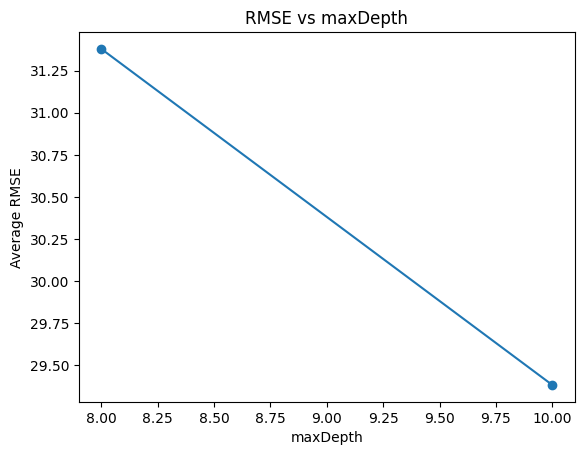

In [0]:
import matplotlib.pyplot as plt

results_df = results_spark_df.toPandas()

depth_avg = results_df.groupby("maxDepth")["rmse"].mean()

plt.figure()
plt.plot(depth_avg.index, depth_avg.values, marker='o')
plt.xlabel("maxDepth")
plt.ylabel("Average RMSE")
plt.title("RMSE vs maxDepth")
plt.show()

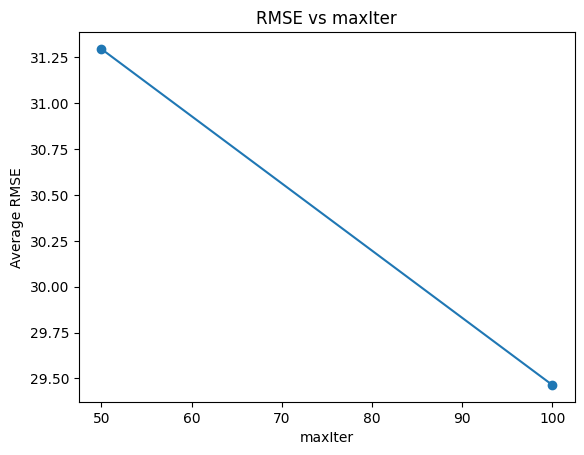

In [0]:
iter_avg = results_df.groupby("maxIter")["rmse"].mean()

plt.figure()
plt.plot(iter_avg.index, iter_avg.values, marker='o')
plt.xlabel("maxIter")
plt.ylabel("Average RMSE")
plt.title("RMSE vs maxIter")
plt.show()

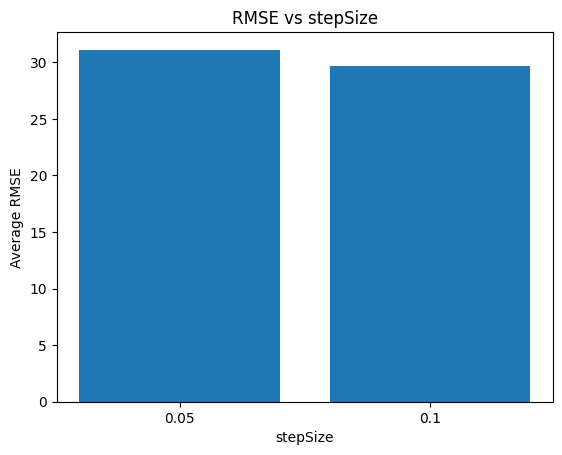

In [0]:
step_avg = results_df.groupby("stepSize")["rmse"].mean()

plt.figure()
plt.bar(step_avg.index.astype(str), step_avg.values)
plt.xlabel("stepSize")
plt.ylabel("Average RMSE")
plt.title("RMSE vs stepSize")
plt.show()

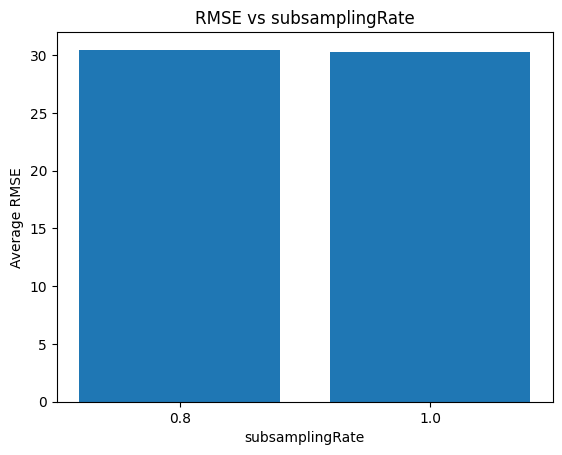

In [0]:
sub_avg = results_df.groupby("subsamplingRate")["rmse"].mean()

plt.figure()
plt.bar(sub_avg.index.astype(str), sub_avg.values)
plt.xlabel("subsamplingRate")
plt.ylabel("Average RMSE")
plt.title("RMSE vs subsamplingRate")
plt.show()

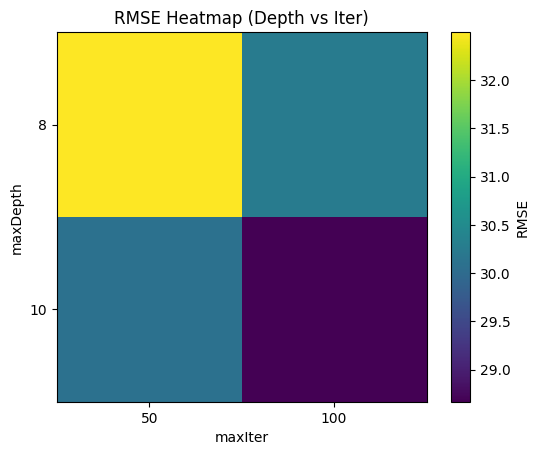

In [0]:
pivot = results_df.pivot_table(
    values="rmse",
    index="maxDepth",
    columns="maxIter"
)

plt.figure()
plt.imshow(pivot.values)
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("maxIter")
plt.ylabel("maxDepth")
plt.title("RMSE Heatmap (Depth vs Iter)")
plt.colorbar(label="RMSE")
plt.show()

Best configuration identified:

- maxDepth = 10
- maxIter = 100
- stepSize = 0.1
- subsamplingRate = 1.0

Observations:
- Increasing maxDepth improved performance, indicating deeper trees capture traffic patterns better.
- Higher maxIter reduced RMSE, showing benefit from additional boosting iterations.
- stepSize = 0.1 performed better than 0.05, suggesting faster learning was effective.
- Subsampling did not significantly impact performance.

Conclusion:
The model performs best with a deeper tree and higher number of iterations, balancing complexity and learning capacity.